In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
rows, cols = 34, 20
i, j = np.indices((rows, cols))

epsilon = 1e-2

In [9]:
def _not(x):
    return 1 - x

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [10]:
def true():
    dist = np.ones((rows, cols))
    dist[0][0] -= epsilon
    return dist

def false():
    dist = np.zeros((rows, cols))
    dist += epsilon
    dist[0][0] += epsilon
    return dist

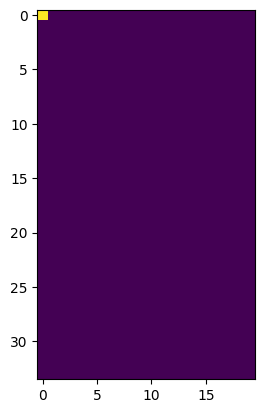

In [11]:
plt.imshow(false())
plt.show()

## CloseTo

In [12]:
def close_to(coord, d, show=False):

    x, y = coord[0], coord[1]
    radius = d

    distances = np.sqrt((i - y)**2 + (j - x)**2)

    sigma = radius / 2
    close_to = np.exp(-distances**2 / (2 * sigma**2)) + epsilon

    if show:
        plt.imshow(close_to, cmap='inferno')
        plt.colorbar()
        plt.show()

    return close_to


## HeightRelation

In [13]:
def height_relation(height, offset, dev, mirror=False, show=False):
    y = height

    distances = (y + offset - i) if mirror else (i - y + offset) 
    height_relation = 1 - np.clip(distances / (dev if dev > 0 else 1), 0, 1) + epsilon

    if show:
        plt.imshow(height_relation, cmap='inferno')
        plt.colorbar()
        plt.show()

    return height_relation

## HasLineOfPass

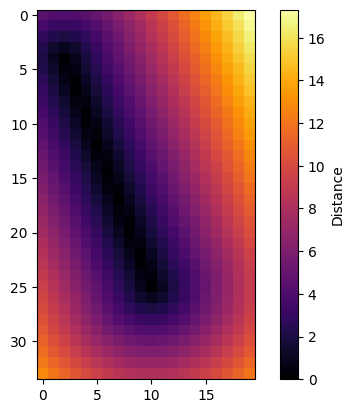

In [14]:
start_x, start_y = 2, 4
end_x, end_y = 10, 25

v = np.array([end_x - start_x, end_y - start_y])
v_norm_sq = v[0]**2 + v[1]**2
v_norm = np.sqrt(v_norm_sq)

t = ((j - start_x) * v[0] + (i - start_y) * v[1]) / v_norm_sq
perp_dist = np.abs(v[0]*(i - start_y) - v[1]*(j - start_x)) / v_norm

dist_to_A = np.sqrt((j - start_x)**2 + (i - start_y)**2)
dist_to_B = np.sqrt((j - end_x)**2 + (i - end_y)**2)

distances = np.where(t < 0, dist_to_A, np.where(t > 1, dist_to_B, perp_dist))

plt.imshow(distances, cmap='inferno')
plt.colorbar(label="Distance")
plt.show()

In [15]:
def has_line_of_pass(start, end, obstacles, radius, tau=None, show=False):
    if tau is None:
        tau = radius / 3.0

    # Unpack teammate's position
    T_x, T_y = end

    # Compute vector from each candidate P to the teammate T
    # Here the candidate P = (i, j)
    v_x, v_y = T_y - i, T_x - j
    norm_v = np.sqrt(v_x**2 + v_y**2) + epsilon

    safety = np.ones((rows, cols))
    
    for (O_y, O_x) in obstacles:

        # Compute vector from candidate P to the opponent O
        w_x, w_y = O_x - i, O_y - j
        
        # Projection along the vector v
        dot = w_x * v_x + w_y * v_y
        t = dot / (norm_v**2)
        
        # Compute the candidate-dependent distance from the opponent to the line
        d = np.where(t < 0, 
                     np.sqrt((O_x - i)**2 + (O_y - j)**2),  # closest to candidate P
                     np.where(t > 1, 
                              np.sqrt((O_x - T_x)**2 + (O_y - T_y)**2),  # closest to teammate T
                              np.abs(v_x * w_y - v_y * w_x) / norm_v))  # perpendicular distance
        
        # Compute a soft safety score for this obstacle.
        # When d >> radius, the sigmoid -> 1; when d << radius, sigmoid -> 0.
        opponent_safety = sigmoid((d - radius) / tau)
        
        # Combine with previous safety scores using a min (the worst-case opponent dominates)
        safety = np.minimum(safety, opponent_safety)
    
    if show:
        plt.imshow(safety, cmap='inferno')
        plt.colorbar()
        for (O_x, O_y) in obstacles: 
            plt.scatter(O_x, O_y, marker='o', color='red', label='Opponent')
        plt.scatter(T_x, T_y, marker='o', color='cyan', label='Teammate')
        plt.show()
        
    return safety


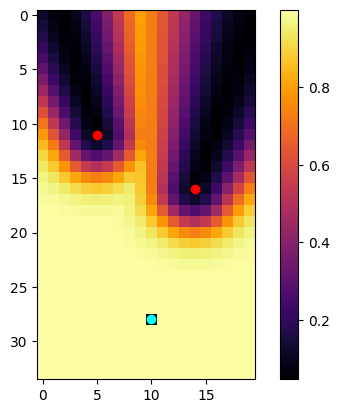

In [16]:
trial = has_line_of_pass((0, 0), (10, 28), [(5, 11), (14, 16)], 3, show=True)

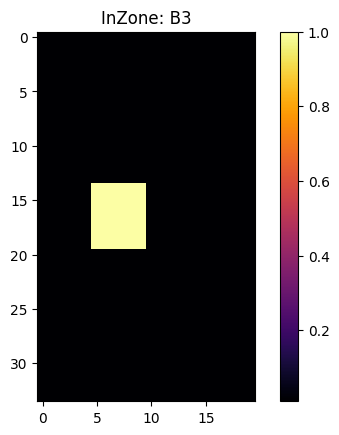

In [17]:
# ---
# Constants for field and zone definitions
FIELD_WIDTH, FIELD_HEIGHT = 20, 34
NUM_ZONES_X, NUM_ZONES_Y = 4, 5
ZONE_WIDTH = FIELD_WIDTH / NUM_ZONES_X  # =5.0
ZONE_HEIGHT = FIELD_HEIGHT / NUM_ZONES_Y  # =6.8

# For InZone, we use these labels.
zone_x_labels = ['A', 'B', 'C', 'D']
zone_y_labels = ['1', '2', '3', '4', '5']

def in_zone(desired_zone, show=False):
    """
    Returns a soft membership field over the grid where cells in the desired zone have score ~1.

    Parameters:
      - desired_zone (str): A string like 'A3' where letter ∈ {A, B, C, D} and digit ∈ {1,2,3,4,5}.
      - show (bool): Whether to plot the resulting mask.
    
    Returns:
      - zone_field (np.ndarray): A 2D potential field (shape: rows x cols).
    """
    # Convert zone string to numeric indices.
    # 'A' -> 0, 'B' -> 1, etc.
    desired_zone_x = zone_x_labels.index(desired_zone[0])
    desired_zone_y = int(desired_zone[1:]) - 1  # assume zones start at 1
    
    # Compute field coordinates for each cell (centered)
    # Here, j corresponds to x and i to y.
    x_coord = j - FIELD_WIDTH / 2 + 0.5
    y_coord = i - FIELD_HEIGHT / 2 + 0.5
    
    # Compute the zone indices by floor dividing by zone dimension.
    # (Since our grid cells are evenly spaced, note that (j+0.5) already does the centering.)
    zone_idx_x = ((x_coord + FIELD_WIDTH/2) // ZONE_WIDTH).astype(int)
    zone_idx_y = ((y_coord + FIELD_HEIGHT/2) // ZONE_HEIGHT).astype(int)
    
    # Create a binary mask: 1 if the cell is in the desired zone, epsilon otherwise.
    zone_field = np.where((zone_idx_x == desired_zone_x) & (zone_idx_y == desired_zone_y),
                            1.0, epsilon)
    
    if show:
        plt.imshow(zone_field, cmap='inferno')
        plt.title(f"InZone: {desired_zone}")
        plt.colorbar()
        plt.show()
    
    return zone_field

# Example usage:
mask = in_zone('B3', show=True)


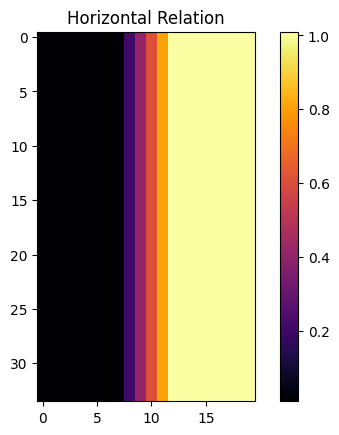

In [18]:
def horizontal_relation(x, offset, dev, mirror=False, show=False):

    distances = (x + offset - j) if mirror else (j - x + offset)
    h_relation = 1 - np.clip(distances / (dev if dev > 0 else 1), 0, 1) + epsilon

    if show:
        plt.imshow(h_relation, cmap='inferno')
        plt.title("Horizontal Relation")
        plt.colorbar()
        plt.show()

    return h_relation

# Example usage:
h_field = horizontal_relation(10, offset=2, dev=5, mirror=True, show=True)


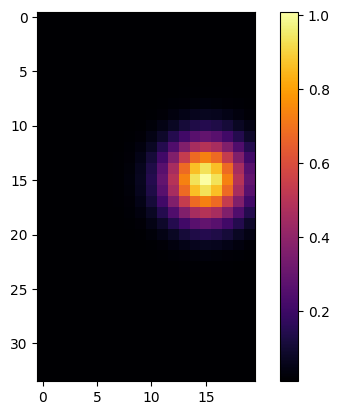

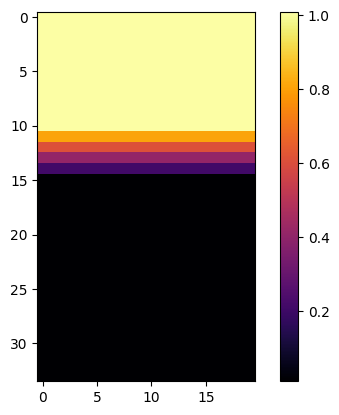

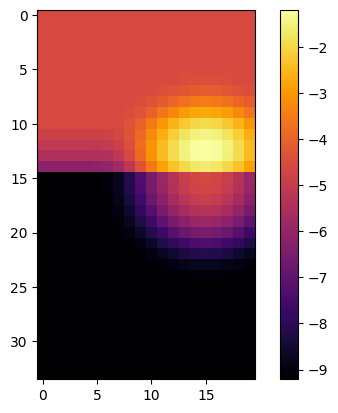

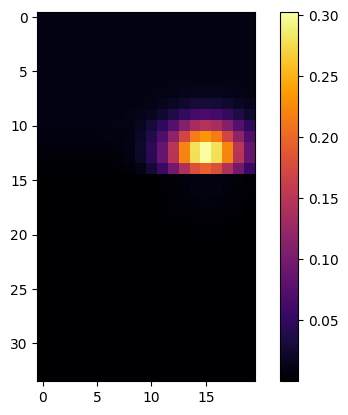

In [19]:
constraints = [
    close_to((15, 15), 5, show=True),
    height_relation(15, 5, 5, show=True),
    # has_line_of_pass((4, 5), (20, 23), [(17, 10)], 5, show=True)
]

final = sum(np.log(constraints))

plt.imshow(final, cmap='inferno')
plt.colorbar()
plt.show()

plt.imshow(np.exp(final), cmap='inferno')
plt.colorbar()
plt.show()


P(background) = 0.0
(13, 15)


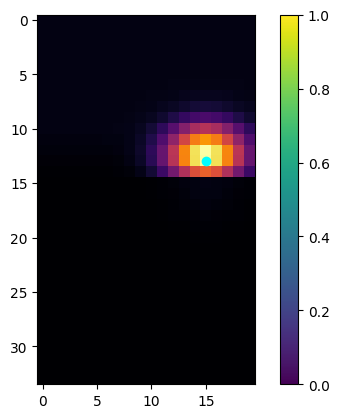

In [20]:
def sample(dist, min_val=0.1):
    # zero out anything below min_val
    filtered = np.where(dist >= min_val, dist, 0.0)
    
    total = filtered.sum()
    if total == 0:
        raise ValueError("No elements exceed the threshold!")
    
    probs = filtered / total
    flat = probs.ravel()

    mask_bg = (dist>=min_val) & (dist < 0.1)
    M_bg = dist[mask_bg].sum()
    M_tot= dist.sum()
    print("P(background) =", M_bg/M_tot)

    
    idx = np.random.choice(flat.size, p=flat)
    return np.unravel_index(idx, dist.shape)
    

exp_final = np.exp(final)
sampled_coord = sample(exp_final, min_val=0.1)

print(sampled_coord)

plt.figure()
plt.imshow(exp_final, cmap='inferno')
plt.scatter(sampled_coord[1], sampled_coord[0], color='cyan', marker='o')
plt.colorbar()
plt.show()

In [21]:
def check_sample_threshold(sample, dist, min):
    value = dist[sample]
    return value > min

In [22]:
exp_final[0][0]

0.010100000000000236

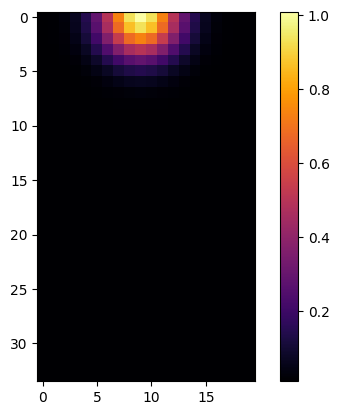

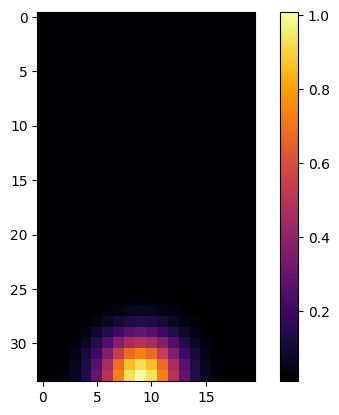

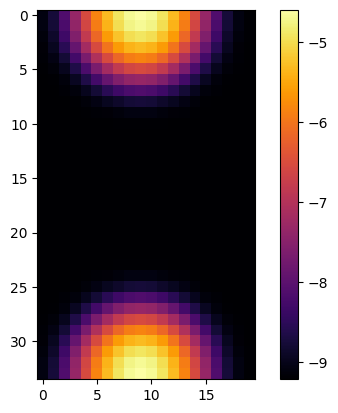

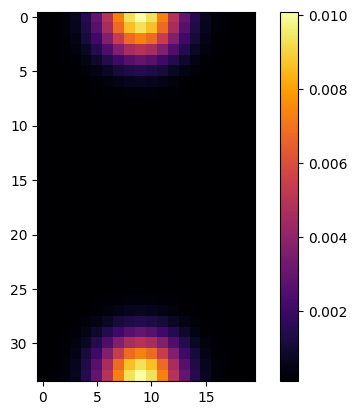

In [23]:
constraints = [
    close_to((9, 0), 5, show=True), # ego/coach
    close_to((9, 33), 5, show=True), # teammtae
]

final = sum(np.log(constraints))

plt.imshow(final, cmap='inferno')
plt.colorbar()
plt.show()

plt.imshow(np.exp(final), cmap='inferno')
plt.colorbar()
plt.show()


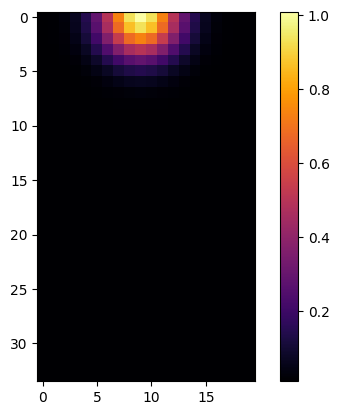

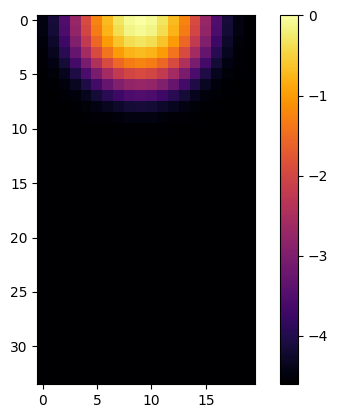

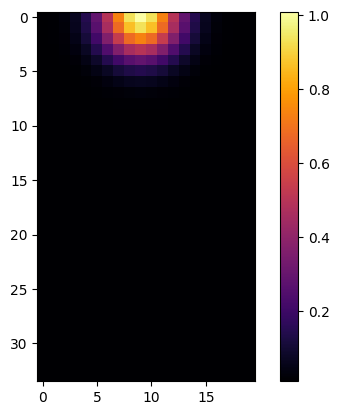

In [24]:
constraints = [
    close_to((9, 0), 5, show=True),
    true(),
]

final = sum(np.log(constraints))

plt.imshow(final, cmap='inferno')
plt.colorbar()
plt.show()

plt.imshow(np.exp(final), cmap='inferno')
plt.colorbar()
plt.show()


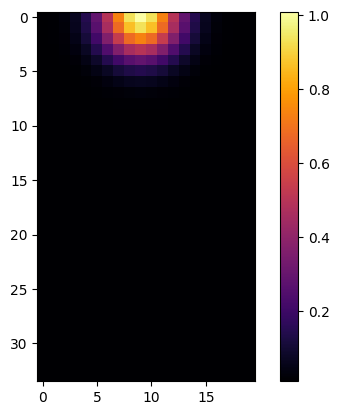

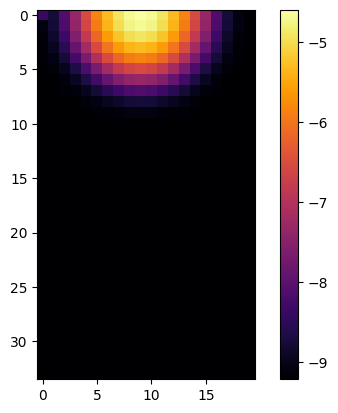

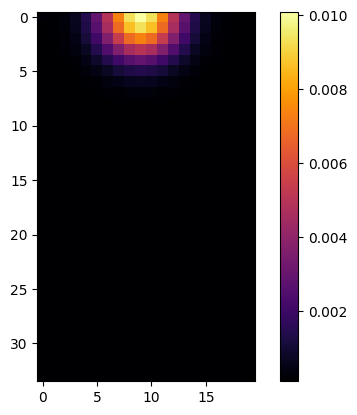

In [25]:
constraints = [
    close_to((9, 0), 5, show=True),
    false(),
]

final = sum(np.log(constraints))

plt.imshow(final, cmap='inferno')
plt.colorbar()
plt.show()

plt.imshow(np.exp(final), cmap='inferno')
plt.colorbar()
plt.show()


In [26]:
constraints = [
    close_to((0, 0), 5),
    has_line_of_pass((0, 0), (10, 28), [(5, 11), (14, 16)], 3),
]

pixel1 = constraints[0][0][0]
pixel2 = constraints[1][0][0]

print(pixel1, pixel2)

print(pixel1 * pixel2)

print()

pixel1 = constraints[0][30][10]
pixel2 = constraints[1][30][10]

print(pixel1, pixel2)

print(pixel1 * pixel2)

1.01 0.1201162194780808
0.1213173816728616

0.01 0.9999951257830202
0.009999951257830202


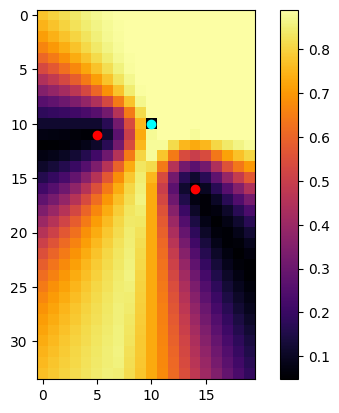

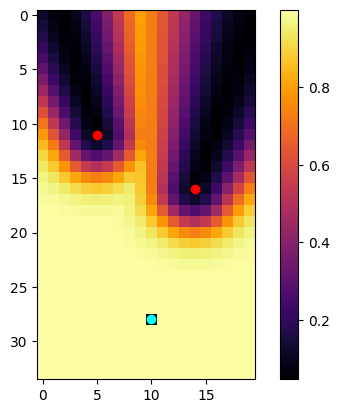

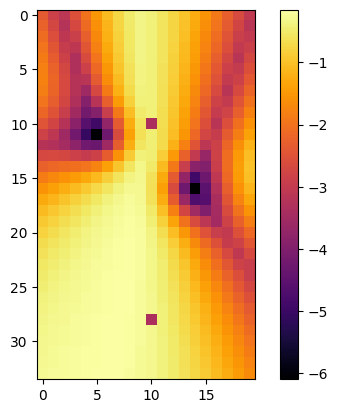

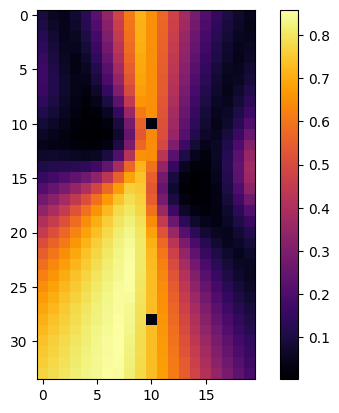

In [150]:
constraints = [
    has_line_of_pass((10, 28), (10, 10), [(5, 11), (14, 16)], 3, show=True),
    has_line_of_pass((10, 10), (10, 28), [(5, 11), (14, 16)], 3, show=True),
]

final = sum(np.log(constraints))

plt.imshow(final, cmap='inferno')
plt.colorbar()
plt.show()

plt.imshow(np.exp(final), cmap='inferno')
plt.colorbar()
plt.show()


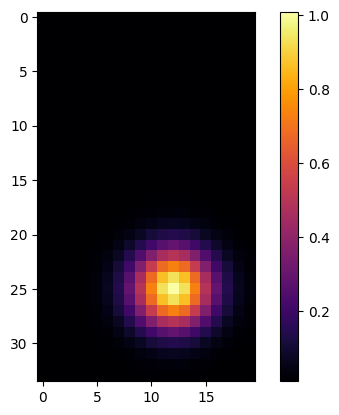

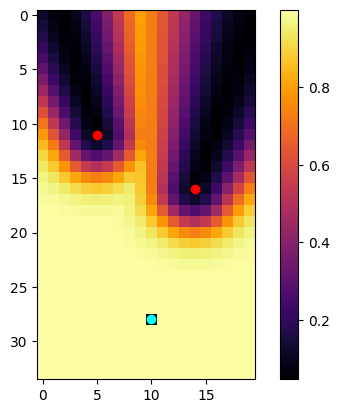

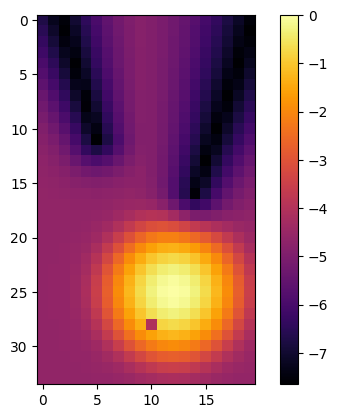

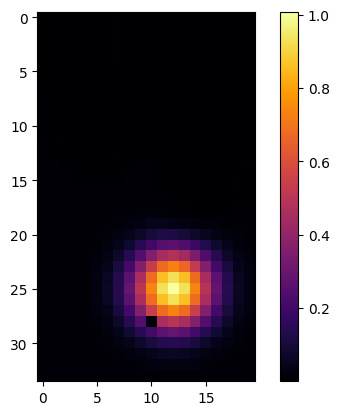

In [27]:
constraints = [
    close_to((12, 25), 5, show=True),
    has_line_of_pass((0, 0), (10, 28), [(5, 11), (14, 16)], 3, show=True),
]

final = sum(np.log(constraints))

plt.imshow(final, cmap='inferno')
plt.colorbar()
plt.show()

plt.imshow(np.exp(final), cmap='inferno')
plt.colorbar()
plt.show()


In [28]:
exp_final = np.exp(final)
sampled_coord = sample(exp_final, min=0.1)

plt.figure()
plt.imshow(exp_final, cmap='inferno')
plt.scatter(sampled_coord[1], sampled_coord[0], color='cyan', marker='o')
plt.colorbar()
plt.show()

TypeError: sample() got an unexpected keyword argument 'min'

In [ ]:
# 17 -> 0
# -17 -> 34

In [111]:
def sample_from(dist, _min=0.1):

    max_val = dist.max()
    if max_val > 0:
        dist = dist / max_val
        
    filtered = np.where(dist >= _min, dist, 0.0)

    total = filtered.sum()
    if total == 0:
        filtered += epsilon

    probs = filtered / total
    flat = probs.ravel()

    idx = np.random.choice(flat.size, p=flat)
    coord = np.unravel_index(idx, dist.shape)

    x, y = coord[1].item(), coord[0].item()
    print('real sampled', x, y)
    #sample = (x - cols / 2, rows / 2 - y)
    print('Sampled', sample)

    return (x, y)


close to 5 13 2
real sampled 7 15
Sampled (-5, 14)


(7, 15)

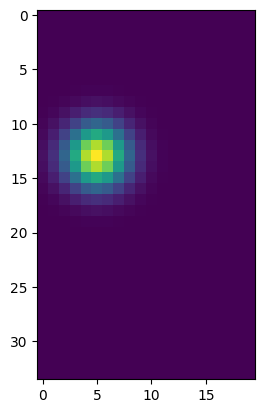

In [112]:
x, y = 5, 13
radius = 2

print('close to', x, y, radius)

distances = np.sqrt((i - y)**2 + (j - x)**2)
close_to = np.exp(-distances**2 / (2 * radius**2)) + epsilon

plt.imshow(close_to)
sample_from(close_to)

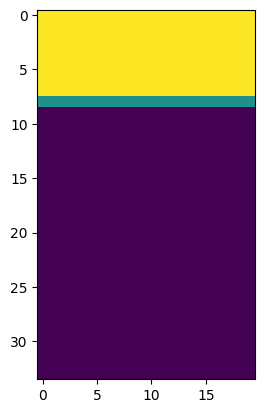

In [113]:
mirror = False
y = 17
offset = 10
dev = 2

distances = (y + offset - i) if mirror else (i - y + offset) 
height_relation = 1 - np.clip(distances / (dev if dev > 0 else 1), 0, 1) + epsilon

plt.imshow(height_relation)

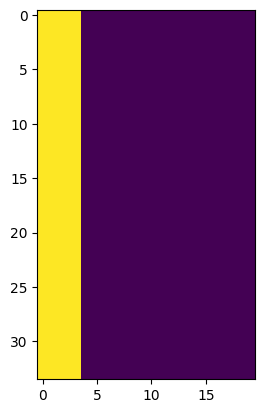

In [146]:
mirror = False
x = 10
offset = 7
dev = 1

distances = (x + offset - j) if mirror else (j - x + offset) 
side_relation = 1 - np.clip(distances / (dev if dev > 0 else 1), 0, 1) + epsilon

plt.imshow(side_relation)

real sampled 0 5
Sampled (5, 4)


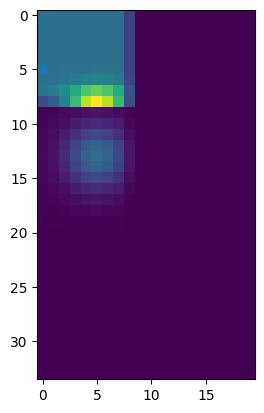

In [142]:
dist = np.exp(sum(np.log([close_to, height_relation, side_relation])))
sample = sample_from(dist)
plt.imshow(dist)
plt.scatter(sample[0], sample[1])

real sampled 17 24
Sampled (0, 0)


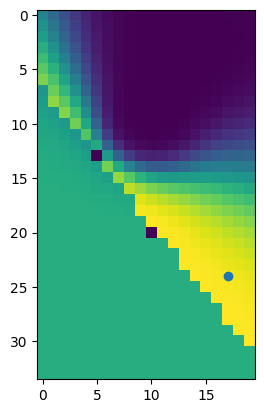

In [161]:
def make_dist(start, end, obstacles, radius, dev=None):

    if dev is None:
        dev = radius / 3.0

    T_x, T_y = end

    v_x, v_y = T_y - i, T_x - j
    norm_v = np.sqrt(v_x**2 + v_y**2) + epsilon

    safety = np.ones((rows, cols))

    for (O_y, O_x) in obstacles:

        w_x, w_y = O_x - i, O_y - j
        
        dot = w_x * v_x + w_y * v_y
        t = dot / (norm_v**2)
        
        d = np.where(t < 0, 
                    np.sqrt((O_x - i)**2 + (O_y - j)**2),
                    np.where(t > 1, 
                            np.sqrt((O_x - T_x)**2 + (O_y - T_y)**2),
                            np.abs(v_x * w_y - v_y * w_x) / norm_v))

        opponent_safety = sigmoid((d - radius) / dev)
        safety = np.minimum(safety, opponent_safety)
        
    return safety

xp, yp = (10, 20)
xr, yr = (5, 13)
obstacles = [(10, 9)]
radiusAvg = 5.0
radiusStd = 1.0

safety_p = make_dist((xp, yp), (xr, yr), obstacles, radiusAvg, radiusStd)
safety_r = make_dist((xr, yr), (xp, yp), obstacles, radiusAvg, radiusStd)

dist = np.exp(sum(np.log([safety_p, safety_r])))
sample = sample_from(dist)
plt.imshow(dist)
plt.scatter(sample[0], sample[1])

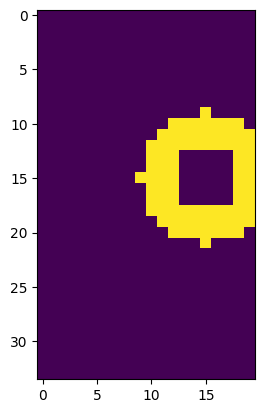

In [166]:
maxAvg = 6
minAvg = 3
operator = 'within'

x, y = 15, 15
distances = np.sqrt((i - y)**2 + (j - x)**2)

if operator == 'within':
    map = np.where((distances >= minAvg) & (distances <= maxAvg),
                    1.0, epsilon)
elif operator == 'less_than':
    map = np.where(distances < maxAvg, 1.0, epsilon)
elif operator == 'greater_than':
    map = np.where(distances > minAvg, 1.0, epsilon)
else:
    map = false()

plt.imshow(map)

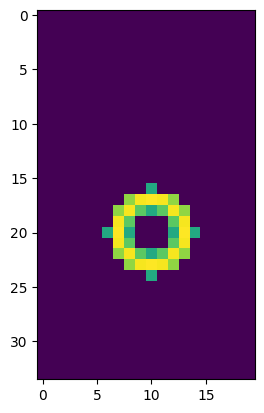

In [170]:
maxAvg = 4
minAvg = 2
operator = 'within'

x, y = 10, 20
distances = np.sqrt((i - y)**2 + (j - x)**2)

ε = epsilon  # background floor

if operator == 'within':
    μ     = (minAvg + maxAvg) / 2.0
    σ     = (maxAvg - minAvg) / 2.0
    mask  = (distances >= minAvg) & (distances <= maxAvg)
    # Gaussian centered at μ, width σ
    bump  = np.exp(-((distances - μ)**2) / (2 * σ**2))
    map = np.where(mask, bump + ε, ε)

elif operator == 'less_than':
    σ     = maxAvg
    mask  = distances < maxAvg
    bump  = np.exp(-(distances**2) / (2 * σ**2))
    map = np.where(mask, bump + ε, ε)

elif operator == 'greater_than':
    σ     = minAvg
    mask  = distances > minAvg
    # bump peaks right at the threshold and decays for farther distances
    bump  = np.exp(-((distances - minAvg)**2) / (2 * σ**2))
    map = np.where(mask, bump + ε, ε)

else:
    print('Invalid operator.')
    map = false()

plt.imshow(map)

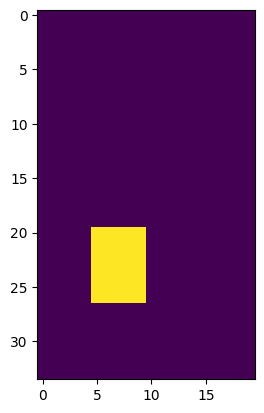

In [173]:
width, height = cols, rows
num_zones_x, num_zones_y = 4, 5
zone_width = width / num_zones_x
zone_height = height / num_zones_y

zone_x_labels = ['A', 'B', 'C', 'D']
zone_y_labels = ['1', '2', '3', '4', '5']

zone = 'B4'
        
zone_x = zone_x_labels.index(zone[0])
zone_y = int(zone[1:]) - 1

x_coord = j - width / 2 + 0.5
y_coord = i - height / 2 + 0.5

zone_idx_x = ((x_coord + width/2) // zone_width).astype(int)
zone_idx_y = ((y_coord + height/2) // zone_height).astype(int)

zone_field = np.where((zone_idx_x == zone_x) & (zone_idx_y == zone_y),
                        1.0, epsilon)

plt.imshow(zone_field)